In [1]:
from preamble_jax import *

2025-08-27 23:56:56,134 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch


# A note about stats
- the arviz mcmc object contains r_hat -> this value should be 1.0 for the perfect model, a 'bad' rhat is 1.15. Less than 1.01 is one criterion people use for judging whether the models have converged. 

In [2]:
# Auto-select a planck function for T < 2500 K
@jit
def spectral_decomp_3T(params,**kwargs):
    # Extract parameters with type conversion
    f_1 = jnp.asarray(params['f_1'], dtype=jnp.float64)
    f_2 = jnp.asarray(params['f_2'], dtype=jnp.float64)
    f_3 = jnp.asarray(params['f_3'], dtype=jnp.float64)
    T_1 = jnp.asarray(params['T_1'], dtype=jnp.float64)
    T_2 = jnp.asarray(params['T_2'], dtype=jnp.float64)
    T_3 = jnp.asarray(params['T_3'], dtype=jnp.float64)

    spec_1, spec_2, spec_3 = [
        get_BTSettl_spectrum_jax(T=Temp)
        for Temp in [T_1,T_2,T_3] ]
    
    # Calculate combined spectrum
    _f = (f_1*spec_1[1] + f_2*spec_2[1] + f_3*spec_3[1])
    _model_flux = (_f/jnp.mean(_f))
    
    convolved = convolve_spectrum_jax(panchromatic_wavelengths, _model_flux, sigma=filter_sigma)
    binned_model_flux = shone.bin_spectrum(SED_wavelengths, panchromatic_wavelengths, convolved)
    model_flux = (binned_model_flux/jnp.mean(binned_model_flux))

    return model_flux

@jit
def spectral_decomp_4T(params,**kwargs):
    # Extract parameters with type conversion
    f_1 = jnp.asarray(params['f_1'], dtype=jnp.float64)
    f_2 = jnp.asarray(params['f_2'], dtype=jnp.float64)
    f_3 = jnp.asarray(params['f_3'], dtype=jnp.float64)
    f_4 = jnp.asarray(params['f_4'], dtype=jnp.float64)
    T_1 = jnp.asarray(params['T_1'], dtype=jnp.float64)
    T_2 = jnp.asarray(params['T_2'], dtype=jnp.float64)
    T_3 = jnp.asarray(params['T_3'], dtype=jnp.float64)
    T_4 = jnp.asarray(params['T_4'], dtype=jnp.float64)

    spec_1, spec_2, spec_3 = [
        get_BTSettl_spectrum_jax(T=Temp)
        for Temp in [T_1,T_2,T_3] ]
    
    # Calculate combined spectrum
    _f = (f_1*spec_1[1] + f_2*spec_2[1] + f_3*spec_3[1] + f_4*spec_4[1])
    _model_flux = (_f/jnp.mean(_f))
    
    binned_model_flux = shone.bin_spectrum(SED_wavelengths, panchromatic_wavelengths, _model_flux)    
    model_flux = (binned_model_flux/jnp.mean(binned_model_flux))

    return model_flux

In [3]:
def numpyro_model():

    """
    Define the probabilistic model in NUMPYRO
    """
    params = {}

    # Stellar Parameters
    params['f_1'] = numpyro.sample('f_1', dist.Uniform(0.0, 1.0))
    params['f_2'] = numpyro.sample('f_2', dist.Uniform(0.0, 1.0))
    
    params['T_1'] = numpyro.sample('T_1', dist.Uniform(3600, 4500))
    delta_T_1 = numpyro.sample('delta_T_1', dist.Uniform(-1000, 0))
    params['T_2'] = numpyro.deterministic('T_2', (params['T_1'] + delta_T_1) )
    if n_temps == 3:
        params['T_3'] = numpyro.sample('T_3', dist.Uniform(1200, 3000))
        params['f_3'] = numpyro.sample('f_3', dist.Uniform(0.0, 1.0))
    if n_temps == 4:
        params['T_4'] = numpyro.sample('T_4', dist.Uniform(1000, 2300))
        params['f_4'] = numpyro.sample('f_4', dist.Uniform(0.0, 1.0))
    if n_temps == 5:
        params['T_5'] = numpyro.sample('T_5', dist.Uniform(4500, 8000))
        params['f_5'] = numpyro.sample('f_5', dist.Uniform(0.0, 1.0))

    beta = numpyro.sample('beta', dist.Uniform(0, 3))

    numpyro.sample(
        "Obs", dist.Normal(
            loc=spectral_decomp_model(params), 
            scale=(10**beta)*spec_err_jax,
        ), obs=spec_flux_jax
    )

In [4]:
median_model = np.array([1.24611665, 1.24476899, 1.24558651, 1.21748658, 1.21633771,
       1.23365403, 1.23687584, 1.2271226 , 1.20778187, 1.20790813,
       1.20509997, 1.19898947, 1.17927396, 1.17340938, 1.17155728,
       1.17004567, 1.15348096, 1.16528575, 1.16208949, 1.16488743,
       1.16850248, 1.16454057, 1.15955944, 1.15344982, 1.14854707,
       1.13952133, 1.13102131, 1.1288392 , 1.12160546, 1.12069606,
       1.1161467 , 1.10955465, 1.10837387, 1.10235679, 1.08482031,
       1.08122632, 1.07897065, 1.08227402, 1.08183945, 1.07718025,
       1.05499638, 1.03020872, 1.05094458, 1.05875083, 1.04322965,
       1.02242393, 1.01421959, 1.01190188, 1.01105791, 1.00697613,
       1.00267283, 0.99523819, 0.99309213, 0.99591089, 0.9957049 ,
       0.99432959, 0.98620382, 0.96854344, 0.95075968, 0.94779409,
       0.95080342, 0.95139808, 0.94369421, 0.93855839, 0.93096678,
       0.9150034 , 0.91671161, 0.92225136, 0.91991955, 0.91947902,
       0.91882587, 0.9130706 , 0.90273893, 0.89150023, 0.88902586,
       0.88783556, 0.88677318, 0.88441098, 0.87658277, 0.87496713,
       0.88614501, 0.86516567, 0.83746981, 0.86337996, 0.87744497,
       0.87809747, 0.88080394, 0.8768885 , 0.87258517, 0.86790026,
       0.8637671 , 0.87119919, 0.87102225, 0.8627654 , 0.86203931,
       0.86271225, 0.85796823, 0.83928221, 0.83878554, 0.8541899 ,
       0.85248151, 0.85369634, 0.86145131, 0.85995685, 0.8542637 ,
       0.84514012, 0.82182907, 0.81374503, 0.83170398, 0.84704625,
       0.8434384 , 0.83599877, 0.83337641])

In [7]:
SED_bin_edges = np.array([#1.125,1.1290578 , 
                          1.13369066, 
    #1.13832352, 1.14295639, 
    1.14758925,
       #1.15222211, 1.15685497, 
    1.16148784, 
    # 1.1661207 , 1.17075356, 1.17538642, 
    1.18001929, 
    #1.18465215, 1.18928501, 
    1.19391788,
    # 1.19855074, 1.2031836 , 
    1.20781646, 
    # 1.21244933, 1.21708219, 1.22171505, 
    1.22634791, #1.23098078, 1.23561364, 1.2402465 ,
       1.24487937, 
    #1.24951223, 1.25414509, 
    1.25877795, 1.26341082,
       1.26804368, 1.27267654, 1.2773094 , 1.28194227, 1.28657513,
       1.29120799, 1.29584085, 1.30047372, 1.30510658, 1.30973944,
       1.31437231, 1.31900517, 1.32363803, 1.32827089, 1.33290376,
       1.33753662, 1.34216948, 1.34680234, 1.35143521, 1.35606807,
       1.36070093, 1.36533379, 1.36996666, 1.37459952, 1.37923238,
       1.38386525, 1.38849811, 1.39313097, 1.39776383, 1.4023967 ,
       1.40702956, 1.41166242, 1.41629528, 1.42092815, 1.42556101,
       1.43019387, 1.43482674, 1.4394596 , 1.44409246, 1.44872532,
       1.45335819, 1.45799105, 1.46262391, 1.46725677, 1.47188964,
       1.4765225 , 1.48115536, 1.48578822, 1.49042109, 1.49505395,
       1.49968681, 1.50431968, 1.50895254, 1.5135854 , 1.51821826,
       1.52285113, 1.52748399, 1.53211685, 1.53674971, 1.54138258,
       1.54601544, 1.5506483 , 1.55528116, 
    #1.55991403, 1.56454689,
       1.56917975, 
    # 1.57381262, 
    #1.57844548, 1.58307834, 
    1.5877112 ,
       # 1.59234407, 
    #1.59697693, 1.60160979, 1.60624265, 
    1.61087552, 
    
    #1.61550838, 1.62014124, 
    1.62477411,
    # 1.62940697, 1.63403983,1.63867269, 
    1.64330556]) * u.micron



visit = 'F21'
n_temps = 3
SED_err_factor = F21_SED_err_factor

rainbow = read_rainbow(f"../data/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
for i in enumerate(rainbow.wavelength.value):
    rainbow.uncertainty[i,:] = rainbow.uncertainty[i,:] * SED_err_factor[i]
speclc_rainbow = rainbow.bin(wavelength_edges=SED_bin_edges)
predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']
'remove the transit'
out_of_transit = ( speclc_rainbow.trim().mask_transit(period=8.463*u.day, t0=predicted_T0*u.day, duration=0.15*u.day) )
'define the appropriate arrays'
_meanOOTspec = out_of_transit.get_average_spectrum_as_rainbow()
meanOOTspec = _meanOOTspec.flux
meanOOTspec_relative_err = _meanOOTspec.uncertainty.value/meanOOTspec.value
oot_spec_err = meanOOTspec_relative_err.flatten()
SED_wavelengths = (_meanOOTspec.wavelength.value).flatten()
e_per_s = meanOOTspec / exptime
e_per_s_per_angstrom = e_per_s / binwidth
_w, _s, _e = read_sensitivity_curve(grism=grism)
binned_filter_response = bintogrid(_w.value, _s.value, newx=SED_wavelengths)['y'] * u.cm**2 / u.erg
_calibrated_mean_spec = e_per_s_per_angstrom.flatten() / binned_filter_response
calibrated_mean_spec = _calibrated_mean_spec.value/np.nanmean(_calibrated_mean_spec.value)
oot_spec_err = oot_spec_err * calibrated_mean_spec

# Convert to JAX arrays
spec_flux_jax = jnp.array(calibrated_mean_spec)
spec_err_jax = jnp.array(oot_spec_err)
SED_wavelengths = jnp.array(SED_wavelengths)

plt.errorbar(SED_wavelengths,spec_flux_jax,yerr=200*spec_err_jax,fmt='o',ms=3,alpha=0.6)
plt.plot(rainbow.wavelength, median_model)
# for old_edge in F21_speclc_bin_edges:
    # plt.axvline(old_edge.value,zorder=-100,color='k')
for edge in SED_bin_edges:
    plt.axvline(edge.value,alpha=0.5)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

  0%|          | 0/113 [00:00<?, ?it/s]

<ErrorbarContainer object of 3 artists>

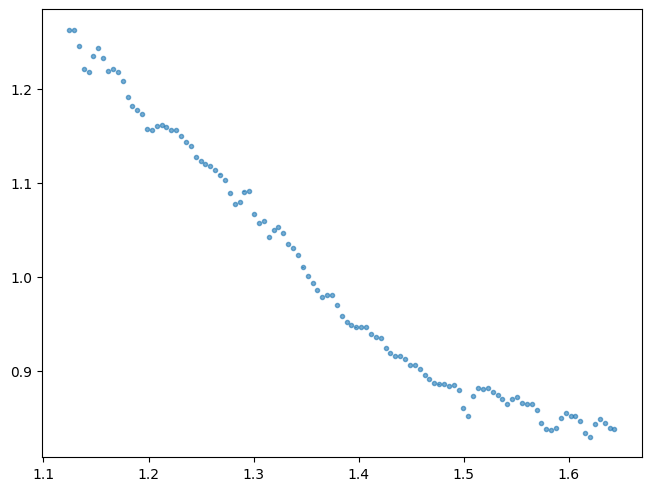

In [5]:
visit = 'F21'
n_temps = 3

'Visit-specific definitions'
#SED_err_factor = F21_SED_err_factor if visit=='F21' else S22_SED_err_factor
filter_sigma = (1.1 * 0.00463 * u.micron) if visit == 'F21' else 0.99 * 0.00246 * u.micron # values 0.99 and 1.1 from https://hst-docs.stsci.edu/wfc3ihb/chapter-7-ir-imaging-with-wfc3/7-6-ir-optical-performance
# SED_err_inflation = 180 if visit =='F21' else 150

# SED_bin_edges = F21_SED_bin_edges if visit=='F21' else S22_SED_bin_edges
# speclc_grid = get_interp_stellar_spectrum(speclc_bin_edges)
# SED_grid = get_interp_stellar_spectrum(SED_bin_edges)

model_designation = f'{n_temps}T_jax_sed_model'

'Things that automatically get re-defined for either visit'
predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']
rainbow = read_rainbow(f"../data/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
speclc_rainbow = rainbow#.bin(dw=4*0.00246*u.micron)
for i in range(len(rainbow.wavelength.value)):
    'ADD CORRECTION TO UNCERTAINTIES'
    speclc_rainbow.uncertainty[i,:] = rainbow.uncertainty[i,:] #* SED_err_factor[i]
'remove the transit'
out_of_transit = ( speclc_rainbow.trim().mask_transit(period=8.463*u.day, t0=predicted_T0*u.day, duration=0.15*u.day) )
'define the appropriate arrays'
_meanOOTspec = out_of_transit.get_average_spectrum_as_rainbow()
meanOOTspec = _meanOOTspec.flux
meanOOTspec_relative_err = _meanOOTspec.uncertainty.value/meanOOTspec.value
oot_spec_err = meanOOTspec_relative_err.flatten()
SED_wavelengths = (_meanOOTspec.wavelength.value).flatten()
e_per_s = meanOOTspec / exptime
e_per_s_per_angstrom = e_per_s / binwidth
_w, _s, _e = read_sensitivity_curve(grism=grism)
binned_filter_response = bintogrid(_w.value, _s.value, newx=SED_wavelengths)['y'] * u.cm**2 / u.erg
_calibrated_mean_spec = e_per_s_per_angstrom.flatten() / binned_filter_response
calibrated_mean_spec = _calibrated_mean_spec.value/np.nanmean(_calibrated_mean_spec.value)
oot_spec_err = oot_spec_err * calibrated_mean_spec

# Convert to JAX arrays
spec_flux_jax = jnp.array(calibrated_mean_spec)
spec_err_jax = jnp.array(oot_spec_err)
SED_wavelengths = jnp.array(SED_wavelengths)

# init_params = {'T_1':1600,
#                'T_2':3100,
#                'T_3':3600,
#                'T_4':4200,
#                'f_1':0.2,
#                'f_2':0.3,
#                'f_3':0.4,
#                'f_4':0.3}

# model = spectral_decomp_model(init_params)
# dof = len(SED_wavelengths) - 6
# rchisq = jnp.sum((spec_flux_jax-model)**2/(spec_err_jax)**2)/dof
plt.errorbar(SED_wavelengths,spec_flux_jax,yerr=spec_err_jax,fmt='o',ms=3,alpha=0.6)
# plt.plot(SED_wavelengths, model, color='k',alpha=0.7,label=f'reduced chisq = {rchisq:.2f}')
# plt.legend()

In [ ]:
# Now we set up the sampler!
rng_seed = 42
rng_keys = split(
    PRNGKey(rng_seed), 
    cpu_cores)

sampler = NUTS(
    numpyro_model,
    dense_mass=True)

# Monte Carlo sampling for a number of steps and parallel chains: 
mcmc = MCMC(
    sampler, 
    num_warmup=1_000, # do 20% the number of samples
    num_samples=5_000, # 2K samples per temperature components
    num_chains=cpu_cores
)

# Run the MCMC
mcmc.run(rng_keys)

# arviz converts a numpyro MCMC object to an `InferenceData` object based on xarray:
result = arviz.from_numpyro(mcmc)

# make a corner plot
corner.corner(
    result, 
    # quiet=True, 
);

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

In [ ]:
F21_3T_result = result

In [ ]:
median_params = arviz.summary(result,stat_focus='median')['median']

In [ ]:
result.summary()

In [ ]:
results_dict = {    
}
# pkeys = ['T_1','T_2','T_3','T_4', 'T_5','f_1','f_2','f_3','f_4','f_5']
pkeys = ['T_1','T_2','T_3','f_1','f_2','f_3']
for key in pkeys:
    results_dict[key] = median_params[key]
model = spectral_decomp_model(results_dict)
dof = len(SED_wavelengths) - len(pkeys)
rchisq = jnp.sum((spec_flux_jax-model)**2/(spec_err_jax)**2)/dof
plt.figure(figsize = (10,5))
plt.errorbar(SED_wavelengths,spec_flux_jax,yerr=spec_err_jax,fmt='o',ms=3,alpha=0.6)
plt.plot(SED_wavelengths, model, color='k',alpha=0.7,label=f'reduced chisq = {rchisq:.2f}')
plt.legend()
plt.savefig(f'../figs/{visit}_{model_designation}_specdecomp.png',dpi=300)

From https://num.pyro.ai/en/latest/tutorials/bad_posterior_geometry.html

In general it is difficult to assess whether the samples returned from HMC or NUTS represent accurate (approximate) samples from the posterior. Two general rules of thumb, however, are to look at the effective sample size (ESS) and r_hat diagnostics returned by mcmc.print_summary(). If we see values of r_hat in the range (1.0, 1.05) and effective sample sizes that are comparable to the total number of samples num_samples (assuming thinning=1) then we have good reason to believe that HMC is doing a good job. If, however, we see low effective sample sizes or large r_hats for some of the variables (e.g. r_hat = 1.15) then HMC is likely struggling with the posterior geometry. In the following we will use r_hat as our primary diagnostic metric.

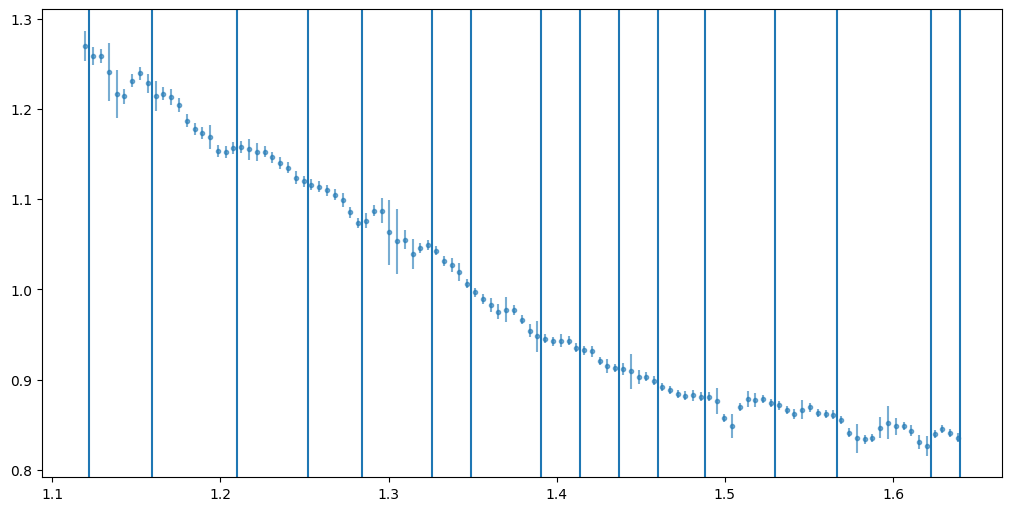

In [8]:
edges = F21_speclc_bin_edges.value

plt.figure(figsize = (10,5))
plt.errorbar(SED_wavelengths,spec_flux_jax,yerr=spec_err_jax,fmt='o',ms=3,alpha=0.6)
# plt.plot(SED_wavelengths, model, color='k',alpha=0.7,label=f'reduced chisq = {rchisq:.2f}')

for edge in edges:
    plt.axvline(edge)
plt.savefig(f'../figs/{visit}_{model_designation}_specdecomp.png',dpi=300)